# ECON FORECASTING FINAL PROJECT

## Setup


### Library import

In [134]:
import pandas as pd 
import numpy as np 
import os 
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

### Data Loading

In [135]:
indpro = pd.read_csv(os.path.join('data', 'indpro.csv'))
spread = pd.read_csv(os.path.join('data', 'T10Y3M.csv'))

print("===== indrpo data ===== ")
print(indpro.head())
print("===== spread data ===== ")
print(spread.head())

===== indrpo data ===== 
  observation_date  INDPRO
0       1919-01-01  4.8739
1       1919-02-01  4.6585
2       1919-03-01  4.5238
3       1919-04-01  4.6046
4       1919-05-01  4.6315
===== spread data ===== 
  observation_date  T10Y3M
0       1982-01-04    2.32
1       1982-01-05    2.24
2       1982-01-06    2.43
3       1982-01-07    2.46
4       1982-01-08    2.50


## Data Preparation

In [136]:
indpro['observation_date'] = pd.to_datetime(indpro['observation_date'])
spread['observation_date'] = pd.to_datetime(spread['observation_date'])
indpro = indpro.sort_values('observation_date')

# g_t = log(IP_t) - log(IP_{t-12})
indpro["IP_growth"] = np.log(indpro["INDPRO"]) - np.log(indpro["INDPRO"].shift(12))

merged_data = pd.merge(indpro, spread, on='observation_date', how='inner')
print("===== Merged Data ===== ")
print(merged_data.iloc[12:].head())


merged_data['Spread_lag12'] = merged_data['T10Y3M'].shift(12)

print("===== Merged + Spread ===== ")
print(merged_data.iloc[12:].head())


===== Merged Data ===== 
   observation_date   INDPRO  IP_growth  T10Y3M
12       1983-06-01  49.1230   0.010264    1.85
13       1983-07-01  49.8546   0.028339    1.88
14       1983-08-01  50.4443   0.049269    2.17
15       1983-09-01  51.1780   0.066178    2.39
16       1983-11-01  51.7993   0.091226    2.89
===== Merged + Spread ===== 
   observation_date   INDPRO  IP_growth  T10Y3M  Spread_lag12
12       1983-06-01  49.1230   0.010264    1.85         -0.19
13       1983-07-01  49.8546   0.028339    1.88          1.04
14       1983-08-01  50.4443   0.049269    2.17          0.23
15       1983-09-01  51.1780   0.066178    2.39          1.38
16       1983-11-01  51.7993   0.091226    2.89          1.26


### Graph

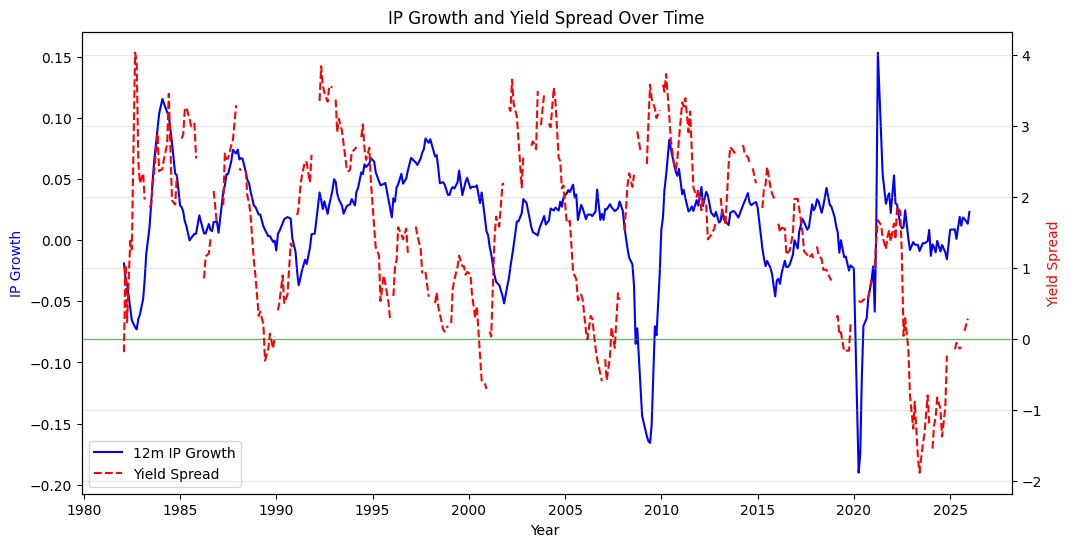

In [137]:
plt.figure(figsize=(12, 6))
ax1 = plt.gca()
ax2 = ax1.twinx()

ip_line = ax1.plot(merged_data['observation_date'], merged_data['IP_growth'], color='blue', label='12m IP Growth')
spread_line = ax2.plot(merged_data['observation_date'], merged_data['T10Y3M'], color='red', linestyle='--', label='Yield Spread')

ax1.set_xlabel('Year ')
ax1.set_ylabel('IP Growth', color='blue')
ax2.set_ylabel('Yield Spread', color='red')

ax2.axhline(0, color='green', linewidth=1, alpha=0.5)

plt.title('IP Growth and Yield Spread Over Time')
plt.grid(True, alpha=0.3)
lines = ip_line + spread_line
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='lower left')

plt.show()

## Train / Test Split

### Train

In [138]:
lag_cols = []
selected_lag = 12
reg_df = merged_data.dropna(subset=['IP_growth', 'Spread_lag12']).copy().reset_index(drop=True)
split = int(len(reg_df) * 0.8)


for i in range(1, selected_lag + 1):
    col_name = f'IP_lag{i}'
    reg_df[col_name] = reg_df['IP_growth'].shift(i)
    lag_cols.append(col_name)

#final_df = reg_df.dropna().reset_index(drop=True)


train = reg_df.iloc[:split]
test = reg_df.iloc[split:]

ytrain = train['IP_growth']

# AR 12
model1 = ARIMA(train['IP_growth'], order=(selected_lag, 0, 0)).fit()

# AR(12) + Spread (MLE)
model2 = ARIMA(train['IP_growth'], order=(selected_lag, 0, 0), exog=train[['Spread_lag12']]).fit()
print(" ===== Model 1 - AR(12) ===== ")
print(model1.summary())

print(" ===== Model 2 - AR(12) + Spread===== ")
print(model2.summary())


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


 ===== Model 1 - AR(12) ===== 
                               SARIMAX Results                                
Dep. Variable:              IP_growth   No. Observations:                  263
Model:                ARIMA(12, 0, 0)   Log Likelihood                 821.974
Date:                Tue, 21 Apr 2026   AIC                          -1615.948
Time:                        22:36:51   BIC                          -1565.937
Sample:                             0   HQIC                         -1595.850
                                - 263                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0207      0.008      2.662      0.008       0.005       0.036
ar.L1          0.9531      0.050     19.109      0.000       0.855       1.051
ar.L2          0.3049

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### Test

In [139]:
# (In Sample)Train performance
pred1_train = model1.fittedvalues
pred2_train = model2.fittedvalues

# AR(12)
mae1_train = mean_absolute_error(ytrain.iloc[selected_lag:], pred1_train.iloc[selected_lag:])
rmse1_train = np.sqrt(mean_squared_error(ytrain.iloc[selected_lag:], pred1_train.iloc[selected_lag:]))

# AR(12) + Spread
mae2_train = mean_absolute_error(ytrain.iloc[selected_lag:], pred2_train.iloc[selected_lag:])
rmse2_train = np.sqrt(mean_squared_error(ytrain.iloc[selected_lag:], pred2_train.iloc[selected_lag:]))


print(" ===== Model 1 - AR(12) ===== ")
print(f"MAE: {mae1_train:.4f}, RMSE: {rmse1_train:.4f}")

print(" ===== Model 2 - AR(12) + Spread ===== ")
print(f"MAE: {mae2_train:.4f}, RMSE: {rmse2_train:.4f}")


 ===== Model 1 - AR(12) ===== 
MAE: 0.0077, RMSE: 0.0106
 ===== Model 2 - AR(12) + Spread ===== 
MAE: 0.0077, RMSE: 0.0106


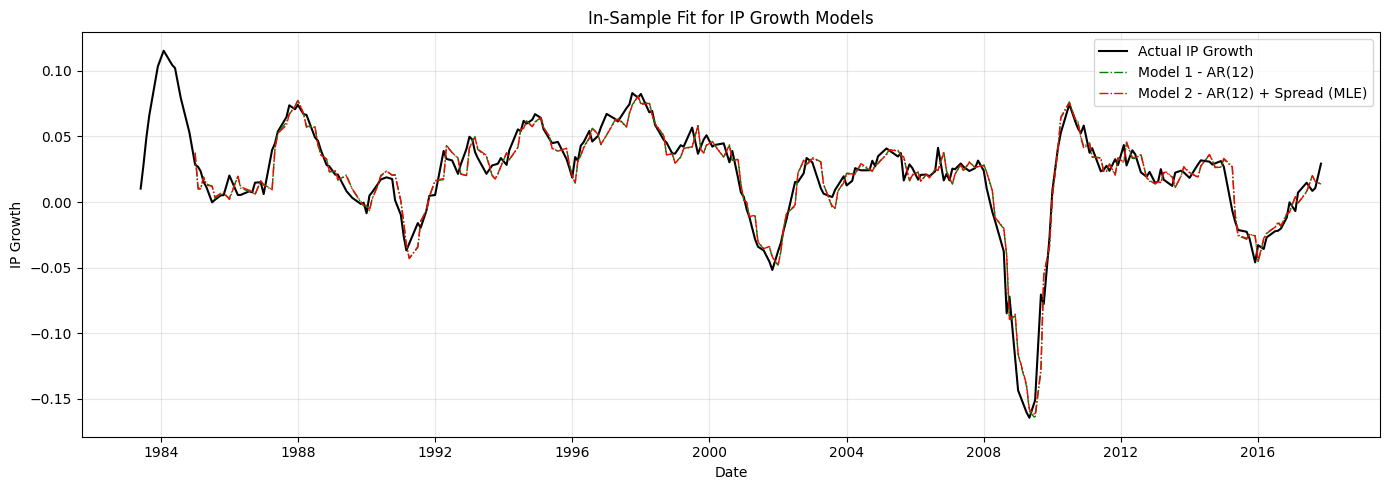

In [140]:
# In-sample 
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train['observation_date'], ytrain.values, label='Actual IP Growth', color='black', linewidth=1.5)
ax.plot(train['observation_date'].iloc[selected_lag:], pred1_train.iloc[selected_lag:].values, 
        label='Model 1 - AR(12)', color='green', linestyle='-.', linewidth=1)
ax.plot(train['observation_date'].iloc[selected_lag:], pred2_train.iloc[selected_lag:].values, 
        label='Model 2 - AR(12) + Spread (MLE)', color='red', linestyle='-.', linewidth=1)

ax.set_title('In-Sample Fit for IP Growth Models')
ax.set_xlabel('Date')
ax.set_ylabel('IP Growth')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [141]:
# Out Sample Test 
ytest = test['IP_growth']

pred1_test_list = []
pred2_test_list = []

for i in range(len(test)):
    history_y = reg_df['IP_growth'].iloc[:split + i]
    history_x = reg_df[['Spread_lag12']].iloc[:split + i]
    future_x  = reg_df[['Spread_lag12']].iloc[[split + i]]
    
    m1 = ARIMA(history_y, order=(selected_lag, 0, 0)).fit()
    pred1_test_list.append(float(m1.forecast(steps=1).iloc[0]))
    
    m2 = ARIMA(history_y, order=(selected_lag, 0, 0), exog=history_x).fit()
    pred2_test_list.append(float(m2.forecast(steps=1, exog=future_x).iloc[0]))

pred1_test = np.array(pred1_test_list)
pred2_test = np.array(pred2_test_list)
mae1  = mean_absolute_error(ytest, pred1_test)
rmse1 = np.sqrt(mean_squared_error(ytest, pred1_test))
mae2  = mean_absolute_error(ytest, pred2_test)
rmse2 = np.sqrt(mean_squared_error(ytest, pred2_test))

print(" ===== Model 1 - AR(12) ===== ")
print(f"MAE: {mae1:.4f}, RMSE: {rmse1:.4f}")
print(" ===== Model 2 - AR(12) + Spread ===== ")
print(f"MAE: {mae2:.4f}, RMSE: {rmse2:.4f}")


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.wa

 ===== Model 1 - AR(12) ===== 
MAE: 0.0203, RMSE: 0.0378
 ===== Model 2 - AR(12) + Spread ===== 
MAE: 0.0205, RMSE: 0.0380


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


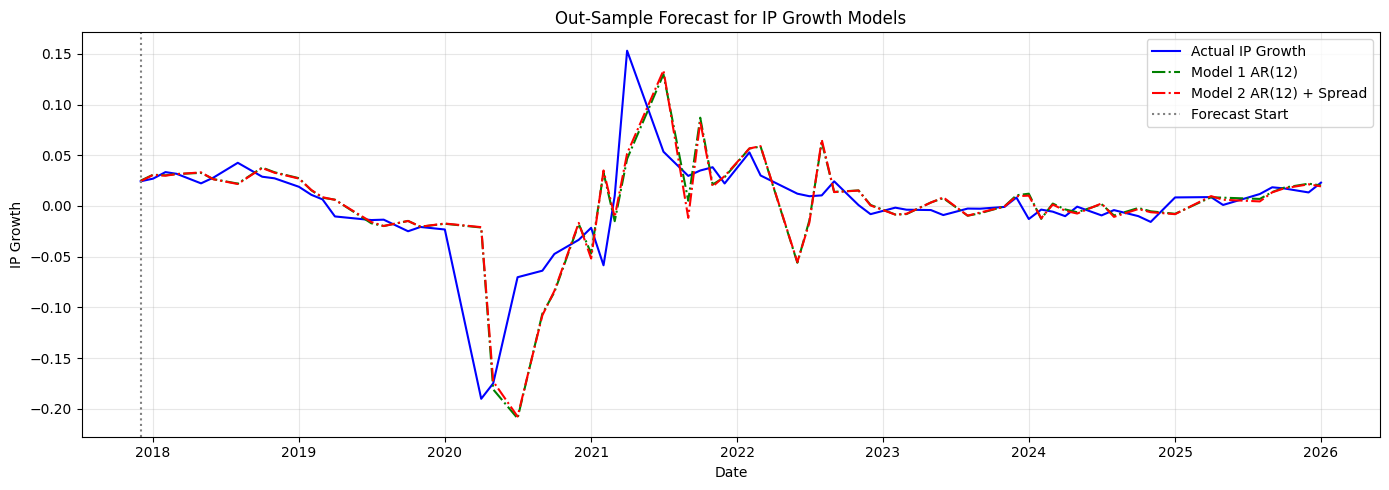

In [142]:
plt.figure(figsize=(14, 5))
plt.plot(test['observation_date'], ytest.values, label='Actual IP Growth', color='blue')
plt.plot(test['observation_date'], pred1_test, label='Model 1 AR(12)', color='green', linestyle='-.')
plt.plot(test['observation_date'], pred2_test, label='Model 2 AR(12) + Spread', color='red', linestyle='-.')
plt.axvline(x=test['observation_date'].iloc[0], color='gray', linestyle=':', label='Forecast Start')
plt.title('Out-Sample Forecast for IP Growth Models')
plt.xlabel('Date')
plt.ylabel('IP Growth')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Forecasting

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


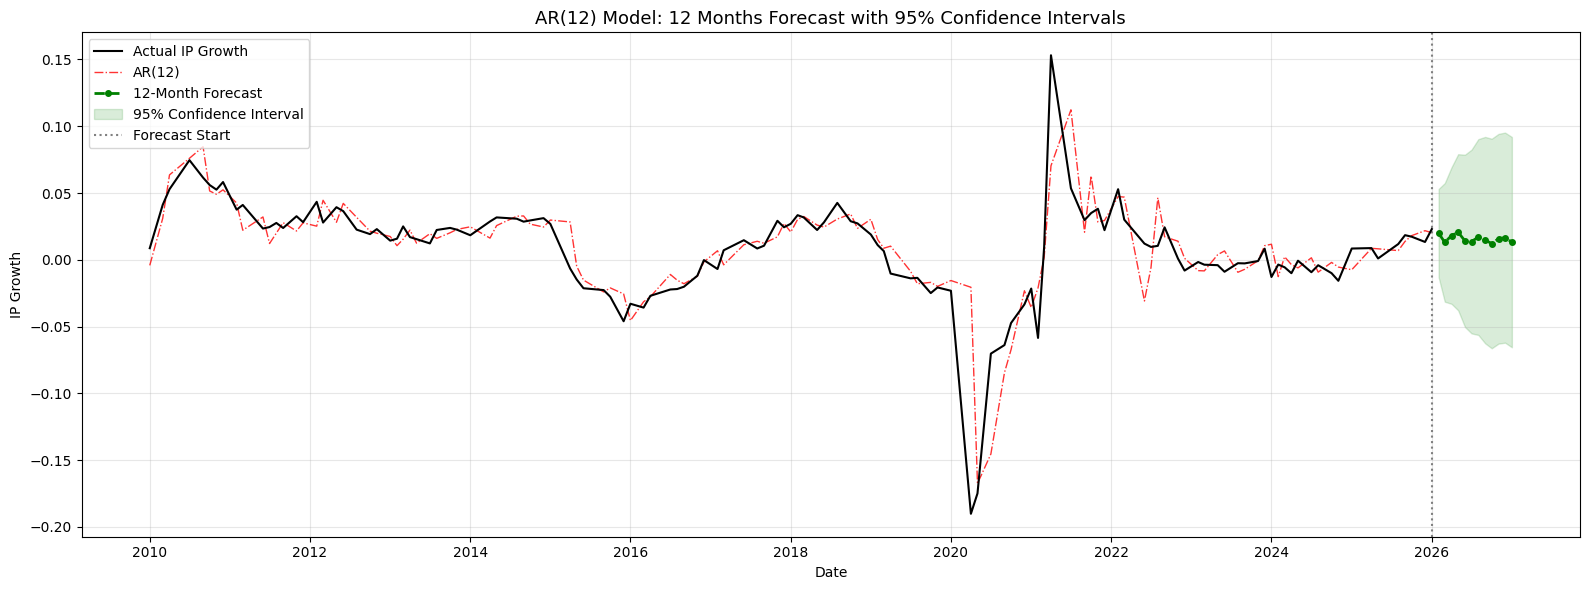

In [151]:

best_model = ARIMA(reg_df['IP_growth'], order=(12, 0, 0)).fit()

model_pred = best_model.fittedvalues

model_result = best_model.get_forecast(steps=12)
model_mean = model_result.predicted_mean
forecast_ci = model_result.conf_int(alpha=0.05)  # 95% CI

last_date = reg_df['observation_date'].iloc[-1]
future_dates = pd.date_range(start=last_date, periods=13, freq='MS')[1:]

display_start = pd.Timestamp('2010-01-01')
display_df = reg_df['observation_date'] >= display_start

fig, ax = plt.subplots(figsize=(16, 6))

# Original Data
ax.plot(reg_df['observation_date'][display_df], reg_df['IP_growth'][display_df],
        color='black', linewidth=1.5, label='Actual IP Growth', zorder=3)

# Test Data
insample_mask = reg_df['observation_date'].iloc[12:].reset_index(drop=True) >= display_start
ax.plot(reg_df['observation_date'].iloc[12:][insample_mask.values], 
        model_pred.iloc[12:][insample_mask.values],
        color='red', linewidth=1, linestyle='-.',
        label='AR(12)', alpha=0.8)

# 12-month forecast
ax.plot(future_dates, model_mean,
        color='green', linewidth=2, linestyle='--',
        marker='o', markersize=4, label='12-Month Forecast')

# 95% CI shading
ax.fill_between(future_dates,
                forecast_ci.iloc[:, 0],
                forecast_ci.iloc[:, 1],
                color='green', alpha=0.15, label='95% Confidence Interval')

# Forecast start line
ax.axvline(x=last_date, color='gray', linestyle=':',
           linewidth=1.5, label='Forecast Start')

ax.set_title('AR(12) Model: 12 Months Forecast with 95% Confidence Intervals', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('IP Growth')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()